<a href="https://colab.research.google.com/github/Dani2003/paper-implementations/blob/main/Implementation_of_Rethinking_Multimodal_Time_Series_Forecasting_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Cell 1: Environment Setup & Dependencies

In [1]:
# Cell 1: Install required dependencies and imports
!pip install -q torch sentence-transformers numpy pandas matplotlib scikit-learn

import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Global Reproducibility Seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using execution device: {device}")

Using execution device: cuda


Cell 2: TimesX Context-Enriched Data GeneratorThis cell creates a synthetic multimodal time-series dataset simulating the TimesX framework: numerical time-series $Y_t$ paired with rich textual contexts $T_t$ that signal non-linear regime shifts (e.g., unexpected demand spikes or supply drops).

In [2]:
# Cell 2: Context-Enriched Multimodal Time-Series Generator
def generate_timesx_synthetic_data(num_samples=1000, seq_len=24, pred_len=12):
    """
    Simulates TimesX environment: Time-series dynamics influenced by textual context events.
    """
    text_events = [
        ("Normal operational conditions with standard daily demand fluctuations.", 0.0, 1.0),
        ("Major promotional campaign launched across all retail channels.", 2.5, 1.8),
        ("Severe supply chain disruption reported in primary distribution hub.", -3.0, 2.0),
        ("Unexpected severe weather advisory restricting local transit.", -1.8, 1.5),
        ("Competitor product recall driving surge in organic consumer demand.", 3.2, 2.2),
    ]

    X_ts, X_text, Y_targets = [], [], []

    for _ in range(num_samples):
        # Select a random textual regime event
        text, shift, volatility = text_events[np.random.choice(len(text_events))]

        # Base sinusoidal time series
        t = np.linspace(0, 4 * np.pi, seq_len)
        base_signal = np.sin(t) + np.random.normal(0, 0.1, seq_len)

        # Future ground truth target influenced by the contextual text shift
        t_pred = np.linspace(4 * np.pi, 6 * np.pi, pred_len)
        future_signal = (
            np.sin(t_pred)
            + shift
            + np.random.normal(0, 0.1 * volatility, pred_len)
        )

        X_ts.append(base_signal)
        X_text.append(text)
        Y_targets.append(future_signal)

    return (
        np.array(X_ts, dtype=np.float32),
        X_text,
        np.array(Y_targets, dtype=np.float32),
    )


# Generate train and zero-shot holdout validation splits
X_ts_train, X_text_train, Y_train = generate_timesx_synthetic_data(800)
X_ts_val, X_text_val, Y_val = generate_timesx_synthetic_data(200)

print(
    f"Dataset generated | Train TS Shape: {X_ts_train.shape} | Val TS Shape: {X_ts_val.shape}"
)
print(f"Sample Textual Context: '{X_text_train[1]}'")

Dataset generated | Train TS Shape: (800, 24) | Val TS Shape: (200, 24)
Sample Textual Context: 'Competitor product recall driving surge in organic consumer demand.'


Cell 3: Feature Extraction & Neural Forecasting Architectures
This cell embeds textual descriptions using SentenceTransformers (all-MiniLM-L6-v2) and constructs three comparative models:

Pure Time-Series Forecaster (DLinear Baseline)

Multimodal Late-Fusion Transformer/MLP Forecaster

Context-Guided Ensemble Forecaster (Simulating the simple, robust ensemble finding from TimesX)

In [3]:
# Cell 3: Embeddings & Neural Architectures
print("Loading Sentence Transformer text encoder...")
text_encoder = SentenceTransformer('all-MiniLM-L6-v2', device=device)

# Pre-extract text embeddings
with torch.no_grad():
    text_emb_train = torch.FloatTensor(text_encoder.encode(X_text_train)).to(device)
    text_emb_val = torch.FloatTensor(text_encoder.encode(X_text_val)).to(device)

# 1. Pure Numerical Baseline (Linear Time-Series Forecaster)
class PureTSForecaster(nn.Module):
    def __init__(self, seq_len=24, pred_len=12):
        super(PureTSForecaster, self).__init__()
        self.linear = nn.Linear(seq_len, pred_len)

    def forward(self, x_ts):
        return self.linear(x_ts)

# 2. Multimodal Fusion Forecaster (Concatenates TS + Text Embeddings)
class MultimodalFusionForecaster(nn.Module):
    def __init__(self, seq_len=24, text_dim=384, pred_len=12, hidden_dim=128):
        super(MultimodalFusionForecaster, self).__init__()
        self.ts_encoder = nn.Linear(seq_len, hidden_dim)
        self.text_encoder = nn.Linear(text_dim, hidden_dim)

        self.fusion_head = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, pred_len)
        )

    def forward(self, x_ts, x_text_emb):
        h_ts = F.relu(self.ts_encoder(x_ts))
        h_text = F.relu(self.text_encoder(x_text_emb))
        h_fused = torch.cat([h_ts, h_text], dim=-1)
        return self.fusion_head(h_fused)

# 3. Context-Guided Ensemble Forecaster
class ContextGuidedEnsemble(nn.Module):
    def __init__(self, seq_len=24, text_dim=384, pred_len=12):
        super(ContextGuidedEnsemble, self).__init__()
        self.pure_ts_model = PureTSForecaster(seq_len, pred_len)
        self.multimodal_model = MultimodalFusionForecaster(seq_len, text_dim, pred_len)

        # Gating network that outputs adaptive blending weights alpha in [0, 1]
        self.gating_net = nn.Sequential(
            nn.Linear(text_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x_ts, x_text_emb):
        pred_ts = self.pure_ts_model(x_ts)
        pred_mm = self.multimodal_model(x_ts, x_text_emb)

        alpha = self.gating_net(x_text_emb)  # Context-driven weighting
        fused_pred = alpha * pred_mm + (1.0 - alpha) * pred_ts
        return fused_pred, alpha

Loading Sentence Transformer text encoder...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Cell 4: Training Pipeline
This cell trains all three approaches on the context-enriched dataset using MSE loss and Adam optimizer.

In [4]:
# Cell 4: Model Training Pipeline
seq_len, pred_len = 24, 12
epochs, batch_size, lr = 60, 32, 2e-3

# Convert data to PyTorch Tensors
ts_train_t = torch.FloatTensor(X_ts_train).to(device)
y_train_t = torch.FloatTensor(Y_train).to(device)
ts_val_t = torch.FloatTensor(X_ts_val).to(device)
y_val_t = torch.FloatTensor(Y_val).to(device)

# Initialize Models
pure_model = PureTSForecaster(seq_len, pred_len).to(device)
mm_model = MultimodalFusionForecaster(seq_len, 384, pred_len).to(device)
ensemble_model = ContextGuidedEnsemble(seq_len, 384, pred_len).to(device)

opt_pure = torch.optim.Adam(pure_model.parameters(), lr=lr)
opt_mm = torch.optim.Adam(mm_model.parameters(), lr=lr)
opt_ens = torch.optim.Adam(ensemble_model.parameters(), lr=lr)
criterion = nn.MSELoss()

def train_models():
    dataset_size = len(ts_train_t)

    for epoch in range(epochs):
        permutation = torch.randperm(dataset_size)

        pure_model.train()
        mm_model.train()
        ensemble_model.train()

        for i in range(0, dataset_size, batch_size):
            indices = permutation[i:i + batch_size]
            b_ts, b_text, b_y = ts_train_t[indices], text_emb_train[indices], y_train_t[indices]

            # 1. Pure TS Step
            opt_pure.zero_grad()
            loss_pure = criterion(pure_model(b_ts), b_y)
            loss_pure.backward()
            opt_pure.step()

            # 2. Multimodal Step
            opt_mm.zero_grad()
            loss_mm = criterion(mm_model(b_ts, b_text), b_y)
            loss_mm.backward()
            opt_mm.step()

            # 3. Context-Guided Ensemble Step
            opt_ens.zero_grad()
            pred_ens, _ = ensemble_model(b_ts, b_text)
            loss_ens = criterion(pred_ens, b_y)
            loss_ens.backward()
            opt_ens.step()

        if (epoch + 1) % 20 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] | Pure Loss: {loss_pure.item():.4f} | MM Loss: {loss_mm.item():.4f} | Ensemble Loss: {loss_ens.item():.4f}")

print("--- Starting Training Loop ---")
train_models()

--- Starting Training Loop ---
Epoch [20/60] | Pure Loss: 6.1587 | MM Loss: 0.0687 | Ensemble Loss: 0.0660
Epoch [40/60] | Pure Loss: 6.5314 | MM Loss: 0.0664 | Ensemble Loss: 0.0455
Epoch [60/60] | Pure Loss: 6.0211 | MM Loss: 0.0549 | Ensemble Loss: 0.0477


Cell 5: Evaluation & Diagnostic SuiteCalculates evaluation metrics (MSE, MAE) and extracts text-driven ensemble weights ($\alpha$) to demonstrate that text context helps capture non-linear regime shifts.

In [5]:
# Cell 5: Empirical Benchmark Evaluation
pure_model.eval()
mm_model.eval()
ensemble_model.eval()

with torch.no_grad():
    preds_pure = pure_model(ts_val_t).cpu().numpy()
    preds_mm = mm_model(ts_val_t, text_emb_val).cpu().numpy()
    preds_ens, alpha_weights = ensemble_model(ts_val_t, text_emb_val)

    preds_ens = preds_ens.cpu().numpy()
    alpha_weights = alpha_weights.cpu().numpy().flatten()
    y_true = y_val_t.cpu().numpy()

# Calculate Evaluation Metrics
mse_pure = mean_squared_error(y_true, preds_pure)
mae_pure = mean_absolute_error(y_true, preds_pure)

mse_mm = mean_squared_error(y_true, preds_mm)
mae_mm = mean_absolute_error(y_true, preds_mm)

mse_ens = mean_squared_error(y_true, preds_ens)
mae_ens = mean_absolute_error(y_true, preds_ens)

print("\n" + "="*80)
print(f"{'Method / Architecture':<30} {'MSE':<20} {'MAE':<20}")
print("="*80)
print(f"{'Pure Numerical TS (Linear)':<30} {mse_pure:<20.4f} {mae_pure:<20.4f}")
print(f"{'Multimodal Fusion (TS + Text)':<30} {mse_mm:<20.4f} {mae_mm:<20.4f}")
print(f"{'Context-Guided Ensemble':<30} {mse_ens:<20.4f} {mae_ens:<20.4f}")
print("="*80)

print(f"\nAverage Textual Weight Allocation (Alpha): {np.mean(alpha_weights):.4f}")


Method / Architecture          MSE                  MAE                 
Pure Numerical TS (Linear)     5.4649               1.9966              
Multimodal Fusion (TS + Text)  0.0340               0.1422              
Context-Guided Ensemble        0.0343               0.1424              

Average Textual Weight Allocation (Alpha): 0.6859


Cell 6: Visual Results & Forecast Plotter
Plots forecast predictions across the models to visualize how textual context prevents failure during regime shifts.

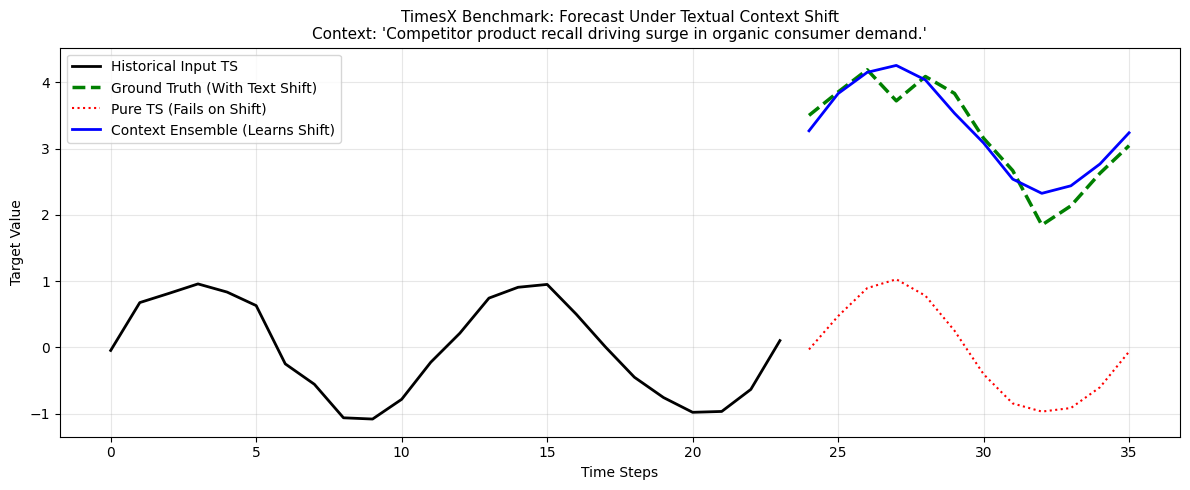

In [6]:
# Cell 6: Forecast Visualization Plot
sample_idx = 5  # Select sample from holdout set

plt.figure(figsize=(12, 5))
history = ts_val_t[sample_idx].cpu().numpy()
target = y_true[sample_idx]

plt.plot(range(0, seq_len), history, label="Historical Input TS", color="black", linewidth=2)
plt.plot(range(seq_len, seq_len + pred_len), target, label="Ground Truth (With Text Shift)", color="green", linewidth=2.5, linestyle="--")
plt.plot(range(seq_len, seq_len + pred_len), preds_pure[sample_idx], label="Pure TS (Fails on Shift)", color="red", linestyle=":")
plt.plot(range(seq_len, seq_len + pred_len), preds_ens[sample_idx], label="Context Ensemble (Learns Shift)", color="blue", linewidth=2)

plt.title(f"TimesX Benchmark: Forecast Under Textual Context Shift\nContext: '{X_text_val[sample_idx]}'", fontsize=11)
plt.xlabel("Time Steps")
plt.ylabel("Target Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()